# Market Risk Analytics in Python

## Project objective

The objective of this project is to build a Python-based market risk analytics workflow for a multi-asset portfolio.

The project will measure historical risk, downside risk, diversification, stress scenario impact, and simulated future outcomes using daily market data.

This project is for educational and analytical purposes only and is not investment advice.

## Step 1: Define the portfolio

For the first version of this project, I will analyze a simplified multi-asset ETF portfolio.

The portfolio includes exposure to:

- U.S. large-cap equities
- U.S. growth equities
- U.S. small-cap equities
- Developed international equities
- Emerging-market equities
- U.S. investment-grade bonds
- Gold

The goal is not to create the perfect investment portfolio. The goal is to create a realistic portfolio that allows me to study risk, diversification, volatility, drawdowns, VaR, CVaR, stress testing, and Monte Carlo simulation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", None)

tickers = ["SPY", "QQQ", "IWM", "EFA", "EEM", "AGG", "GLD"]

weights = np.array([0.30, 0.20, 0.10, 0.10, 0.10, 0.15, 0.05])

portfolio = pd.DataFrame({
    "Ticker": tickers,
    "Weight": weights,
    "Weight (%)": weights * 100,
    "Role": [
        "U.S. large-cap equity exposure",
        "U.S. growth and technology exposure",
        "U.S. small-cap equity exposure",
        "Developed international equity exposure",
        "Emerging-market equity exposure",
        "U.S. investment-grade bond exposure",
        "Gold / alternative defensive exposure"
    ]
})

portfolio

,Ticker,Weight,Weight (%),Role
0,SPY,0.30,30.0,U.S. large-cap equity exposure
1,QQQ,0.20,20.0,U.S. growth and technology exposure
2,IWM,0.10,10.0,U.S. small-cap equity exposure
3,EFA,0.10,10.0,Developed international equity exposure
4,EEM,0.10,10.0,Emerging-market equity exposure
5,AGG,0.15,15.0,U.S. investment-grade bond exposure
6,GLD,0.05,5.0,Gold / alternative defensive exposure


In [2]:
if not np.isclose(weights.sum(), 1.0):
    raise ValueError("Portfolio weights must sum to 1.")

print(f"Total portfolio weight: {weights.sum():.2%}")

Total portfolio weight: 100.00%


## Step 2: Choose the analysis period

For this project, I will use daily historical data from 2019-01-01 to the latest available market data at the time the notebook is run.

This period was selected because it includes multiple market environments, including the COVID-19 crash, the post-COVID recovery, the 2022 inflation and interest-rate shock, the 2023–2024 recovery period, and the most recent market conditions.

Because the end date updates when the notebook is rerun, the results may change over time. This makes the project more realistic as a living market risk analytics workflow.

In [3]:
start_date = "2019-01-01"
end_date = None  # Use latest available market data

print(f"Analysis period starts on: {start_date}")
print("Analysis period ends at the latest available market data.")

Analysis period starts on: 2019-01-01
Analysis period ends at the latest available market data.


## Step 3: Download historical price data

In this step, I download daily historical adjusted closing prices for all selected ETFs.

Adjusted prices are used because they account for corporate actions such as dividends and splits, making them more appropriate for return and risk calculations.

In [4]:
import yfinance as yf

price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = price_data["Close"]

prices.head()

/Users/jimenachinchilla/market-risk-analytics-python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
Date,,,,,,,
2019-01-02,86.043762,33.319096,47.469452,121.330002,122.977821,148.040848,224.382523
2019-01-03,86.399017,32.714996,47.040565,122.430000,120.776924,143.204300,219.028152
2019-01-04,86.140648,33.770046,48.480988,121.440002,125.288322,149.331238,226.364655
2019-01-07,85.995346,33.846607,48.667118,121.860001,127.480133,151.109100,228.149475
2019-01-08,85.930756,33.974247,48.982712,121.529999,129.434494,152.475967,230.292999


In [5]:
print("Price data shape:", prices.shape)
print("Start date:", prices.index.min())
print("End date:", prices.index.max())

prices.tail()

Price data shape: (1873, 7)
Start date: 2019-01-02 00:00:00
End date: 2026-06-15 00:00:00


Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
Date,,,,,,,
2026-06-09,98.370003,65.820000,102.900002,390.779999,285.019989,707.830017,737.049988
2026-06-10,98.309998,64.660004,101.570000,374.579987,282.049988,693.690002,725.429993
2026-06-11,98.879997,67.500000,104.730003,386.320007,290.410004,717.119995,737.760010
2026-06-12,98.760002,67.879997,105.019997,386.540009,292.950012,721.340027,741.750000
2026-06-15,98.849998,69.750000,104.080002,396.549988,294.640015,744.000000,754.830017


In [6]:
missing_values = pd.DataFrame({
    "Missing Values": prices.isna().sum(),
    "Missing (%)": prices.isna().mean() * 100
})

missing_values

,Missing Values,Missing (%)
Ticker,,
AGG,0,0.0
EEM,0,0.0
EFA,0,0.0
GLD,0,0.0
IWM,0,0.0
QQQ,0,0.0
SPY,0,0.0


In [7]:
prices = prices.dropna()

print("Cleaned price data shape:", prices.shape)
print("Cleaned start date:", prices.index.min())
print("Cleaned end date:", prices.index.max())

Cleaned price data shape: (1873, 7)
Cleaned start date: 2019-01-02 00:00:00
Cleaned end date: 2026-06-15 00:00:00


## Step 4: Calculate daily returns

In this step, I convert adjusted closing prices into daily percentage returns.

Risk modeling is based on returns rather than raw prices because returns measure the relative change in value over time.

For the first version of this project, I will use simple daily returns instead of log returns because they are easier to interpret and communicate.

In [8]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
Date,,,,,,,
2019-01-03,0.004129,-0.018131,-0.009035,0.009066,-0.017897,-0.032670,-0.023863
2019-01-04,-0.002990,0.032250,0.030621,-0.008086,0.037353,0.042785,0.033496
2019-01-07,-0.001687,0.002267,0.003839,0.003458,0.017494,0.011905,0.007885
2019-01-08,-0.000751,0.003771,0.006485,-0.002708,0.015331,0.009046,0.009395
2019-01-09,0.000845,0.017781,0.011234,0.006418,0.008255,0.008150,0.004673


In [9]:
print("Returns data shape:", returns.shape)
print("Start date:", returns.index.min())
print("End date:", returns.index.max())

returns.describe()

Returns data shape: (1872, 7)
Start date: 2019-01-03 00:00:00
End date: 2026-06-15 00:00:00


Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
count,1872.000000,1872.000000,1872.000000,1872.000000,1872.000000,1872.000000,1872.000000
mean,0.000081,0.000487,0.000488,0.000694,0.000593,0.000977,0.000724
std,0.003808,0.013516,0.011662,0.011021,0.015846,0.015121,0.012273
min,-0.040011,-0.124793,-0.109902,-0.102742,-0.132669,-0.119788,-0.109424
25%,-0.001743,-0.006098,-0.005132,-0.004760,-0.007937,-0.005942,-0.004241
50%,0.000180,0.000900,0.000768,0.000850,0.001008,0.001445,0.001005
75%,0.001938,0.007447,0.006490,0.006262,0.009570,0.008827,0.006644
max,0.023721,0.080529,0.084731,0.063587,0.091491,0.120031,0.105019


In [10]:
portfolio_returns = returns @ weights

portfolio_returns.head()

Date
2019-01-03   -0.010268
2019-01-04    0.019634
2019-01-07    0.004607
2019-01-08    0.004266
2019-01-09    0.007856
dtype: float64

In [11]:
portfolio_returns_summary = pd.DataFrame({
    "Metric": [
        "Mean Daily Return",
        "Daily Volatility",
        "Minimum Daily Return",
        "Maximum Daily Return"
    ],
    "Value": [
        portfolio_returns.mean(),
        portfolio_returns.std(),
        portfolio_returns.min(),
        portfolio_returns.max()
    ]
})

portfolio_returns_summary

,Metric,Value
0,Mean Daily Return,0.000482
1,Daily Volatility,0.008232
2,Minimum Daily Return,-0.076591
3,Maximum Daily Return,0.057710


In [12]:
cumulative_returns = (1 + portfolio_returns).cumprod()

cumulative_returns.head()

Date
2019-01-03    0.989732
2019-01-04    1.009165
2019-01-07    1.013814
2019-01-08    1.018139
2019-01-09    1.026138
dtype: float64

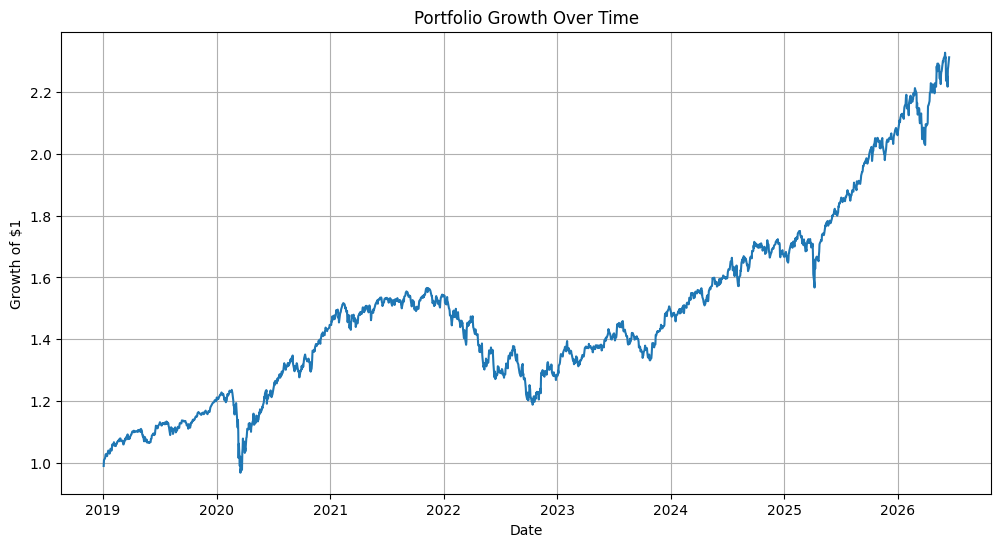

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns)
plt.title("Portfolio Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## Step 5: Measure historical portfolio risk

In this step, I calculate the main historical risk metrics for the portfolio:

- Annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown
- Historical Value at Risk (VaR)
- Historical Conditional Value at Risk (CVaR)

These metrics help quantify return, risk, downside losses, and extreme loss behavior.

In [14]:
trading_days = 252
annual_risk_free_rate = 0.00  # Baseline assumption for first version

annualized_return = (1 + portfolio_returns.mean()) ** trading_days - 1
annualized_volatility = portfolio_returns.std() * np.sqrt(trading_days)

sharpe_ratio = (annualized_return - annual_risk_free_rate) / annualized_volatility

annualized_return, annualized_volatility, sharpe_ratio

(np.float64(0.12911117425851715),
 np.float64(0.13067992187892397),
 np.float64(0.9879954961875453))

In [15]:
running_max = cumulative_returns.cummax()
drawdown = cumulative_returns / running_max - 1

max_drawdown = drawdown.min()

max_drawdown

np.float64(-0.24136920148678487)

In [16]:
confidence_level = 0.95

var_95 = portfolio_returns.quantile(1 - confidence_level)
cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()

var_95, cvar_95

(np.float64(-0.012094763509532556), np.float64(-0.019152585814679688))

In [17]:
risk_summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Historical VaR 95%",
        "Historical CVaR 95%"
    ],
    "Value": [
        annualized_return,
        annualized_volatility,
        sharpe_ratio,
        max_drawdown,
        var_95,
        cvar_95
    ]
})

risk_summary

,Metric,Value
0,Annualized Return,0.129111
1,Annualized Volatility,0.130680
2,Sharpe Ratio,0.987995
3,Maximum Drawdown,-0.241369
4,Historical VaR 95%,-0.012095
5,Historical CVaR 95%,-0.019153


In [18]:
risk_summary_display = risk_summary.copy()

risk_summary_display["Value"] = risk_summary_display.apply(
    lambda row: f"{row['Value']:.2f}" if row["Metric"] == "Sharpe Ratio" else f"{row['Value']:.2%}",
    axis=1
)

risk_summary_display

,Metric,Value
0,Annualized Return,12.91%
1,Annualized Volatility,13.07%
2,Sharpe Ratio,0.99
3,Maximum Drawdown,-24.14%
4,Historical VaR 95%,-1.21%
5,Historical CVaR 95%,-1.92%


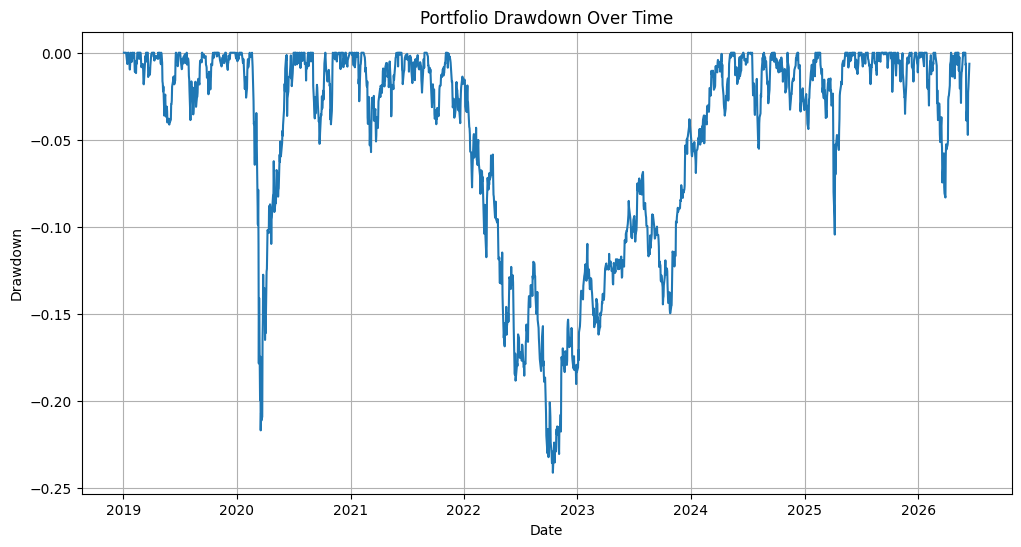

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(drawdown)
plt.title("Portfolio Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

### Initial interpretation

The annualized return shows the average yearly growth rate of the portfolio over the selected historical period.

The annualized volatility measures how much the portfolio returns fluctuate over time.

The Sharpe ratio compares return to risk. In this first version, I assume a 0% risk-free rate as a baseline assumption.

Maximum drawdown shows the worst peak-to-trough decline experienced by the portfolio.

Historical VaR at 95% estimates the daily loss threshold that was only exceeded in the worst 5% of historical days.

Historical CVaR at 95% estimates the average loss on days when losses were worse than the VaR threshold.

## Step 6: Correlation and diversification analysis

In this step, I analyze how the assets move relative to each other.

Correlation is important in risk modeling because a portfolio may appear diversified by holding many assets, but if those assets move together during market stress, the actual diversification benefit may be limited.

I also calculate each asset's contribution to total portfolio risk.

In [20]:
correlation_matrix = returns.corr()

correlation_matrix

Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
Ticker,,,,,,,
AGG,1.000000,0.176693,0.228844,0.310096,0.181452,0.158306,0.162147
EEM,0.176693,1.000000,0.832779,0.265984,0.710964,0.732443,0.752893
EFA,0.228844,0.832779,1.000000,0.244690,0.806611,0.758442,0.851761
GLD,0.310096,0.265984,0.244690,1.000000,0.130797,0.139075,0.124488
IWM,0.181452,0.710964,0.806611,0.130797,1.000000,0.765458,0.866030
QQQ,0.158306,0.732443,0.758442,0.139075,0.765458,1.000000,0.936762
SPY,0.162147,0.752893,0.851761,0.124488,0.866030,0.936762,1.000000


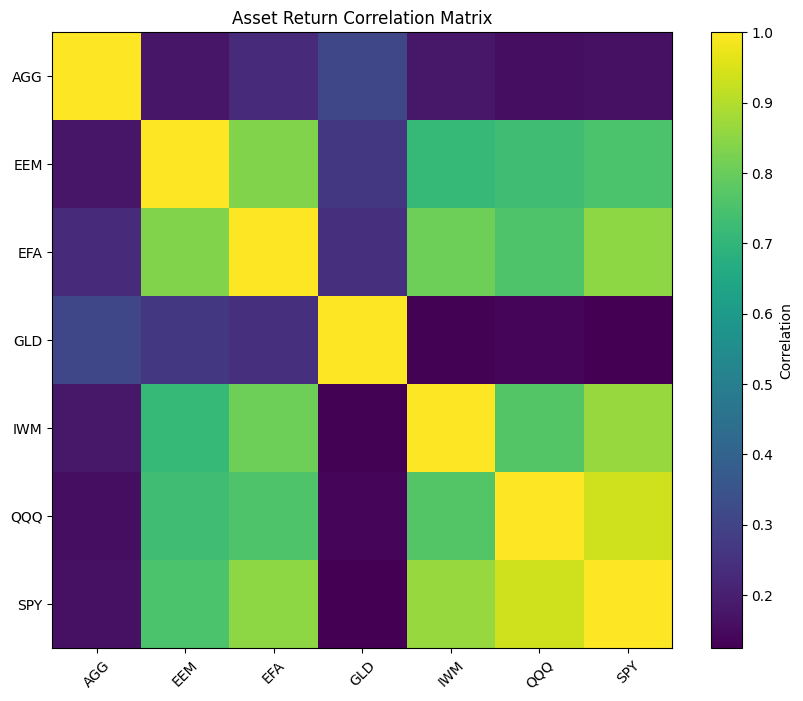

In [21]:
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)

plt.title("Asset Return Correlation Matrix")
plt.show()

In [22]:
# Calculate each asset's average correlation with the rest of the portfolio

correlation_without_self = correlation_matrix.copy()

np.fill_diagonal(correlation_without_self.values, np.nan)

average_correlation = correlation_without_self.mean().sort_values(ascending=False)

average_correlation

Ticker
EFA    0.620521
SPY    0.615680
QQQ    0.581748
EEM    0.578626
IWM    0.576885
AGG    0.202923
GLD    0.202522
dtype: float64

In [23]:
# Annualized covariance matrix
cov_matrix = returns.cov() * trading_days

# Convert weights into a pandas Series so labels stay aligned
weights_series = pd.Series(weights, index=tickers)

# Portfolio volatility using covariance matrix
portfolio_variance = weights_series.T @ cov_matrix @ weights_series
portfolio_volatility_from_cov = np.sqrt(portfolio_variance)

portfolio_volatility_from_cov

np.float64(0.16372202241387998)

In [24]:
# Marginal contribution to risk
marginal_risk_contribution = cov_matrix @ weights_series / portfolio_volatility_from_cov

# Total contribution to portfolio volatility
risk_contribution = weights_series * marginal_risk_contribution

# Percentage contribution to portfolio volatility
risk_contribution_percent = risk_contribution / portfolio_volatility_from_cov

risk_contribution_table = pd.DataFrame({
    "Weight": weights_series,
    "Marginal Risk Contribution": marginal_risk_contribution,
    "Risk Contribution": risk_contribution,
    "Risk Contribution (%)": risk_contribution_percent
}).sort_values("Risk Contribution (%)", ascending=False)

risk_contribution_table

,Weight,Marginal Risk Contribution,Risk Contribution,Risk Contribution (%)
SPY,0.30,0.190030,0.057009,0.348206
QQQ,0.20,0.226399,0.045280,0.276565
IWM,0.10,0.223544,0.022354,0.136538
EEM,0.10,0.180663,0.018066,0.110348
EFA,0.10,0.166314,0.016631,0.101583
AGG,0.15,0.015302,0.002295,0.014020
GLD,0.05,0.041716,0.002086,0.012740


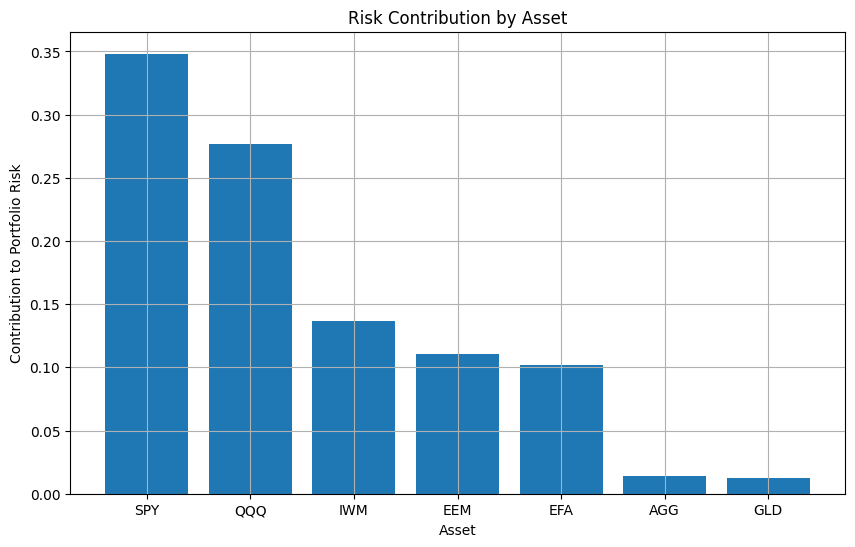

In [25]:
plt.figure(figsize=(10, 6))
plt.bar(risk_contribution_table.index, risk_contribution_table["Risk Contribution (%)"])
plt.title("Risk Contribution by Asset")
plt.xlabel("Asset")
plt.ylabel("Contribution to Portfolio Risk")
plt.grid(True)
plt.show()

### Correlation and diversification interpretation

The correlation matrix shows how closely the assets move together.

Assets with high positive correlations may provide less diversification benefit because they tend to rise and fall together.

Assets with lower or negative correlations may provide more diversification benefit because they behave differently from the rest of the portfolio.

The risk contribution analysis shows which assets contribute the most to total portfolio volatility. An asset can have a smaller portfolio weight but still contribute meaningfully to risk if it has high volatility or high correlation with other assets.

## Step 7: Stress testing

In this step, I apply hypothetical market shock scenarios to estimate how the portfolio could behave under stressed conditions.

Stress testing is useful because historical averages may hide large downside risks. Instead of only asking “what happened on average?”, stress testing asks “what could happen if a bad market scenario occurs?”

Each scenario applies assumed percentage shocks to the assets in the portfolio. The total portfolio impact is calculated by multiplying each asset shock by its portfolio weight.

In [26]:
# Make sure weights are aligned with tickers
weights_series = pd.Series(weights, index=tickers)

stress_scenarios = pd.DataFrame({
    "Equity Market Crash": {
        "SPY": -0.20,
        "QQQ": -0.25,
        "IWM": -0.25,
        "EFA": -0.18,
        "EEM": -0.22,
        "AGG": 0.02,
        "GLD": 0.05
    },
    "Technology Selloff": {
        "SPY": -0.10,
        "QQQ": -0.30,
        "IWM": -0.12,
        "EFA": -0.08,
        "EEM": -0.10,
        "AGG": 0.01,
        "GLD": 0.02
    },
    "Interest Rate Shock": {
        "SPY": -0.08,
        "QQQ": -0.12,
        "IWM": -0.10,
        "EFA": -0.06,
        "EEM": -0.08,
        "AGG": -0.07,
        "GLD": -0.03
    },
    "Emerging Market Crisis": {
        "SPY": -0.05,
        "QQQ": -0.06,
        "IWM": -0.07,
        "EFA": -0.10,
        "EEM": -0.30,
        "AGG": 0.01,
        "GLD": 0.03
    },
    "Broad Risk-Off Event": {
        "SPY": -0.15,
        "QQQ": -0.18,
        "IWM": -0.20,
        "EFA": -0.15,
        "EEM": -0.20,
        "AGG": -0.03,
        "GLD": 0.04
    }
}).T

stress_scenarios

,SPY,QQQ,IWM,EFA,EEM,AGG,GLD
Equity Market Crash,-0.20,-0.25,-0.25,-0.18,-0.22,0.02,0.05
Technology Selloff,-0.10,-0.30,-0.12,-0.08,-0.10,0.01,0.02
Interest Rate Shock,-0.08,-0.12,-0.10,-0.06,-0.08,-0.07,-0.03
Emerging Market Crisis,-0.05,-0.06,-0.07,-0.10,-0.30,0.01,0.03
Broad Risk-Off Event,-0.15,-0.18,-0.20,-0.15,-0.20,-0.03,0.04


In [27]:
stress_results = stress_scenarios.copy()

stress_results["Portfolio Impact"] = stress_scenarios @ weights_series

stress_results

,SPY,QQQ,IWM,EFA,EEM,AGG,GLD,Portfolio Impact
Equity Market Crash,-0.20,-0.25,-0.25,-0.18,-0.22,0.02,0.05,-0.1695
Technology Selloff,-0.10,-0.30,-0.12,-0.08,-0.10,0.01,0.02,-0.1175
Interest Rate Shock,-0.08,-0.12,-0.10,-0.06,-0.08,-0.07,-0.03,-0.0840
Emerging Market Crisis,-0.05,-0.06,-0.07,-0.10,-0.30,0.01,0.03,-0.0710
Broad Risk-Off Event,-0.15,-0.18,-0.20,-0.15,-0.20,-0.03,0.04,-0.1385


In [28]:
stress_results_display = stress_results.copy()

for column in stress_results_display.columns:
    stress_results_display[column] = stress_results_display[column].map(lambda x: f"{x:.2%}")

stress_results_display

,SPY,QQQ,IWM,EFA,EEM,AGG,GLD,Portfolio Impact
Equity Market Crash,-20.00%,-25.00%,-25.00%,-18.00%,-22.00%,2.00%,5.00%,-16.95%
Technology Selloff,-10.00%,-30.00%,-12.00%,-8.00%,-10.00%,1.00%,2.00%,-11.75%
Interest Rate Shock,-8.00%,-12.00%,-10.00%,-6.00%,-8.00%,-7.00%,-3.00%,-8.40%
Emerging Market Crisis,-5.00%,-6.00%,-7.00%,-10.00%,-30.00%,1.00%,3.00%,-7.10%
Broad Risk-Off Event,-15.00%,-18.00%,-20.00%,-15.00%,-20.00%,-3.00%,4.00%,-13.85%


In [29]:
initial_portfolio_value = 10_000

stress_loss_table = pd.DataFrame({
    "Scenario": stress_results.index,
    "Portfolio Impact": stress_results["Portfolio Impact"],
    "Estimated Portfolio Value": initial_portfolio_value * (1 + stress_results["Portfolio Impact"]),
    "Estimated Dollar Gain/Loss": initial_portfolio_value * stress_results["Portfolio Impact"]
})

stress_loss_table

,Scenario,Portfolio Impact,Estimated Portfolio Value,Estimated Dollar Gain/Loss
Equity Market Crash,Equity Market Crash,-0.1695,8305.0,-1695.0
Technology Selloff,Technology Selloff,-0.1175,8825.0,-1175.0
Interest Rate Shock,Interest Rate Shock,-0.0840,9160.0,-840.0
Emerging Market Crisis,Emerging Market Crisis,-0.0710,9290.0,-710.0
Broad Risk-Off Event,Broad Risk-Off Event,-0.1385,8615.0,-1385.0


In [30]:
stress_loss_table_display = stress_loss_table.copy()

stress_loss_table_display["Portfolio Impact"] = stress_loss_table_display["Portfolio Impact"].map(lambda x: f"{x:.2%}")
stress_loss_table_display["Estimated Portfolio Value"] = stress_loss_table_display["Estimated Portfolio Value"].map(lambda x: f"${x:,.2f}")
stress_loss_table_display["Estimated Dollar Gain/Loss"] = stress_loss_table_display["Estimated Dollar Gain/Loss"].map(lambda x: f"${x:,.2f}")

stress_loss_table_display

,Scenario,Portfolio Impact,Estimated Portfolio Value,Estimated Dollar Gain/Loss
Equity Market Crash,Equity Market Crash,-16.95%,"$8,305.00","$-1,695.00"
Technology Selloff,Technology Selloff,-11.75%,"$8,825.00","$-1,175.00"
Interest Rate Shock,Interest Rate Shock,-8.40%,"$9,160.00",$-840.00
Emerging Market Crisis,Emerging Market Crisis,-7.10%,"$9,290.00",$-710.00
Broad Risk-Off Event,Broad Risk-Off Event,-13.85%,"$8,615.00","$-1,385.00"


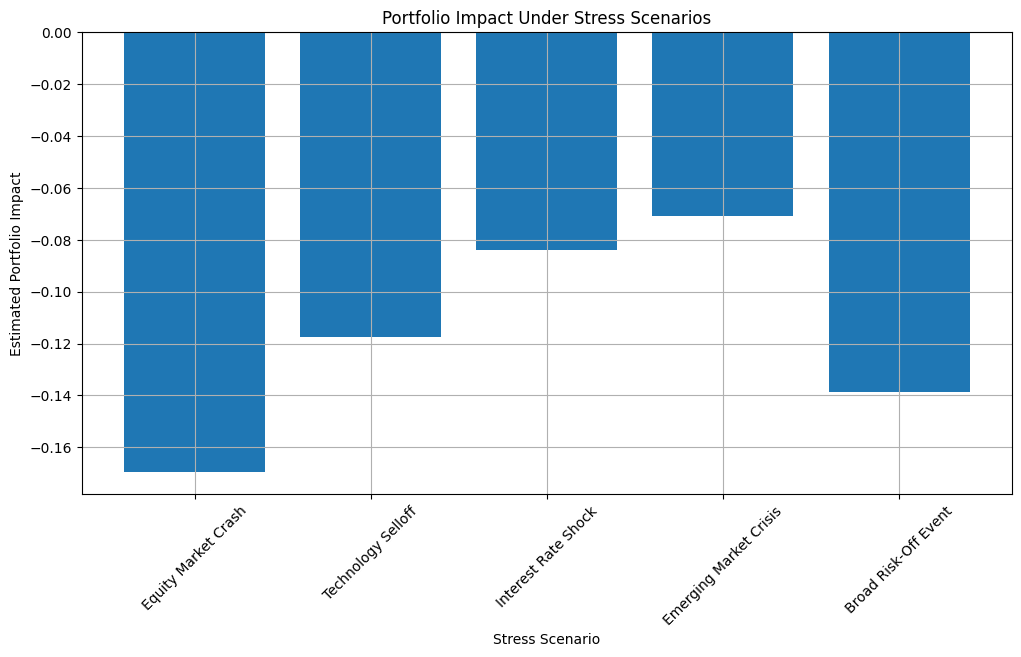

In [31]:
plt.figure(figsize=(12, 6))
plt.bar(stress_results.index, stress_results["Portfolio Impact"])
plt.title("Portfolio Impact Under Stress Scenarios")
plt.xlabel("Stress Scenario")
plt.ylabel("Estimated Portfolio Impact")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Stress testing interpretation

The stress test estimates how the portfolio could respond to different hypothetical market shocks.

The portfolio impact depends on both the size of the shock applied to each asset and the weight of each asset in the portfolio.

Equity-heavy scenarios are expected to hurt the portfolio because most of the portfolio is allocated to equity ETFs.

Bonds and gold may reduce losses in some scenarios, but they may not fully protect the portfolio if the shock affects multiple asset classes at the same time.

The stress test is not a prediction. It is a scenario-based risk tool used to understand possible downside exposure under specific assumptions.

## Step 8: Monte Carlo simulation

In this step, I simulate possible future portfolio outcomes using Monte Carlo simulation.

The simulation uses the historical average daily return and daily volatility of the portfolio as inputs. It then generates many possible future return paths over a one-year horizon.

This helps estimate a range of possible outcomes instead of relying on a single forecast.

For the first version, I use a simple normal distribution assumption. This is a baseline model and will be improved in future versions.

In [32]:
np.random.seed(42)

num_simulations = 10000
forecast_horizon_days = 252
initial_portfolio_value = 10_000

daily_mean_return = portfolio_returns.mean()
daily_volatility = portfolio_returns.std()

print(f"Daily mean return: {daily_mean_return:.4%}")
print(f"Daily volatility: {daily_volatility:.4%}")

Daily mean return: 0.0482%
Daily volatility: 0.8232%


In [33]:
simulated_daily_returns = np.random.normal(
    loc=daily_mean_return,
    scale=daily_volatility,
    size=(forecast_horizon_days, num_simulations)
)

simulated_portfolio_paths = initial_portfolio_value * (1 + simulated_daily_returns).cumprod(axis=0)

simulated_portfolio_paths.shape

(252, 10000)

In [34]:
ending_values = simulated_portfolio_paths[-1, :]
simulated_one_year_returns = ending_values / initial_portfolio_value - 1

simulation_summary = pd.DataFrame({
    "Metric": [
        "Mean Ending Value",
        "Median Ending Value",
        "5th Percentile Ending Value",
        "95th Percentile Ending Value",
        "Worst Simulated Ending Value",
        "Best Simulated Ending Value",
        "Mean One-Year Return",
        "Median One-Year Return",
        "5th Percentile One-Year Return",
        "95th Percentile One-Year Return"
    ],
    "Value": [
        ending_values.mean(),
        np.median(ending_values),
        np.percentile(ending_values, 5),
        np.percentile(ending_values, 95),
        ending_values.min(),
        ending_values.max(),
        simulated_one_year_returns.mean(),
        np.median(simulated_one_year_returns),
        np.percentile(simulated_one_year_returns, 5),
        np.percentile(simulated_one_year_returns, 95)
    ]
})

simulation_summary

,Metric,Value
0,Mean Ending Value,11279.697665
1,Median Ending Value,11191.560252
2,5th Percentile Ending Value,9032.173079
3,95th Percentile Ending Value,13848.072318
4,Worst Simulated Ending Value,7116.334637
5,Best Simulated Ending Value,18169.159447
6,Mean One-Year Return,0.127970
7,Median One-Year Return,0.119156
8,5th Percentile One-Year Return,-0.096783
9,95th Percentile One-Year Return,0.384807


In [35]:
simulation_summary_display = simulation_summary.copy()

money_metrics = [
    "Mean Ending Value",
    "Median Ending Value",
    "5th Percentile Ending Value",
    "95th Percentile Ending Value",
    "Worst Simulated Ending Value",
    "Best Simulated Ending Value"
]

simulation_summary_display["Value"] = simulation_summary_display.apply(
    lambda row: f"${row['Value']:,.2f}" if row["Metric"] in money_metrics else f"{row['Value']:.2%}",
    axis=1
)

simulation_summary_display

,Metric,Value
0,Mean Ending Value,"$11,279.70"
1,Median Ending Value,"$11,191.56"
2,5th Percentile Ending Value,"$9,032.17"
3,95th Percentile Ending Value,"$13,848.07"
4,Worst Simulated Ending Value,"$7,116.33"
5,Best Simulated Ending Value,"$18,169.16"
6,Mean One-Year Return,12.80%
7,Median One-Year Return,11.92%
8,5th Percentile One-Year Return,-9.68%
9,95th Percentile One-Year Return,38.48%


In [36]:
monte_carlo_var_95 = np.percentile(simulated_one_year_returns, 5)
monte_carlo_cvar_95 = simulated_one_year_returns[simulated_one_year_returns <= monte_carlo_var_95].mean()

monte_carlo_risk_summary = pd.DataFrame({
    "Metric": [
        "Monte Carlo VaR 95% - One Year",
        "Monte Carlo CVaR 95% - One Year"
    ],
    "Value": [
        monte_carlo_var_95,
        monte_carlo_cvar_95
    ]
})

monte_carlo_risk_summary["Value"] = monte_carlo_risk_summary["Value"].map(lambda x: f"{x:.2%}")

monte_carlo_risk_summary

,Metric,Value
0,Monte Carlo VaR 95% - One Year,-9.68%
1,Monte Carlo CVaR 95% - One Year,-14.43%


In [37]:
percentiles = np.percentile(
    simulated_portfolio_paths,
    [5, 25, 50, 75, 95],
    axis=1
)

percentile_paths = pd.DataFrame({
    "5th Percentile": percentiles[0],
    "25th Percentile": percentiles[1],
    "Median": percentiles[2],
    "75th Percentile": percentiles[3],
    "95th Percentile": percentiles[4]
})

percentile_paths.head()

,5th Percentile,25th Percentile,Median,75th Percentile,95th Percentile
0,9868.590899,9949.451777,10004.606222,10060.063632,10140.048589
1,9822.256736,9931.422675,10010.008133,10087.777577,10203.942134
2,9777.184378,9916.896898,10013.675649,10111.973688,10253.662193
3,9742.911422,9905.298494,10017.318194,10133.474507,10293.205811
4,9713.945678,9898.462834,10023.144650,10150.435347,10328.923813


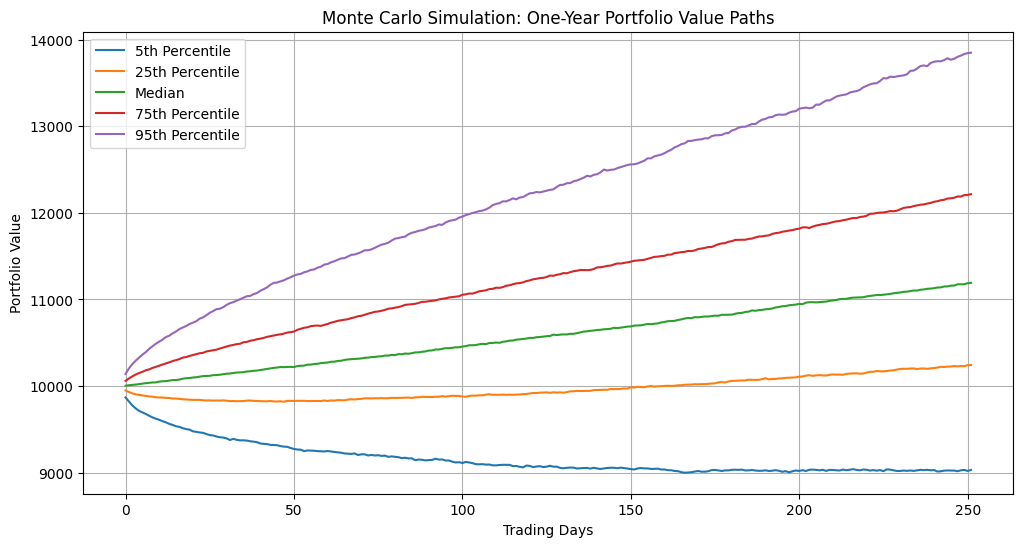

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(percentile_paths["5th Percentile"], label="5th Percentile")
plt.plot(percentile_paths["25th Percentile"], label="25th Percentile")
plt.plot(percentile_paths["Median"], label="Median")
plt.plot(percentile_paths["75th Percentile"], label="75th Percentile")
plt.plot(percentile_paths["95th Percentile"], label="95th Percentile")

plt.title("Monte Carlo Simulation: One-Year Portfolio Value Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

### Monte Carlo simulation interpretation

The Monte Carlo simulation estimates a range of possible future portfolio values over a one-year horizon.

The median path represents the middle simulated outcome, while the 5th and 95th percentile paths show downside and upside scenarios.

The Monte Carlo VaR at 95% estimates the one-year return level below which only 5% of simulated outcomes fall.

The Monte Carlo CVaR at 95% estimates the average return of the worst 5% of simulated outcomes.

This simulation is not a prediction. It is a risk modeling tool based on historical mean return and volatility assumptions.

A key limitation is that the first version assumes normally distributed returns, which may underestimate extreme market events. A future version can improve this by using bootstrapping, fat-tailed distributions, or correlated asset-level simulations.

## Step 9: Results interpretation and professional insights

In this step, I summarize the main findings from the portfolio risk analysis.

The goal is to move beyond calculations and explain what the results mean from a risk management perspective.

This section focuses on:

- Which asset contributes the most to portfolio risk
- Whether the portfolio appears diversified
- How severe the downside risk is
- Which stress scenario causes the largest loss
- What the Monte Carlo simulation suggests about possible future outcomes
- What limitations should be considered

In [39]:
top_risk_asset = risk_contribution_table.index[0]
top_risk_contribution = risk_contribution_table.iloc[0]["Risk Contribution (%)"]

highest_avg_corr_asset = average_correlation.index[0]
highest_avg_corr_value = average_correlation.iloc[0]

lowest_avg_corr_asset = average_correlation.index[-1]
lowest_avg_corr_value = average_correlation.iloc[-1]

worst_stress_scenario = stress_results["Portfolio Impact"].idxmin()
worst_stress_impact = stress_results["Portfolio Impact"].min()

historical_var_loss = -var_95
historical_cvar_loss = -cvar_95

monte_carlo_var_loss = -monte_carlo_var_95
monte_carlo_cvar_loss = -monte_carlo_cvar_95

insight_summary = pd.DataFrame({
    "Question": [
        "Which asset contributes the most to portfolio risk?",
        "Which asset has the highest average correlation with the rest of the portfolio?",
        "Which asset has the lowest average correlation with the rest of the portfolio?",
        "What was the maximum historical drawdown?",
        "What is the estimated 95% daily historical VaR loss?",
        "What is the estimated 95% daily historical CVaR loss?",
        "Which stress scenario caused the worst portfolio loss?",
        "What is the worst stress scenario impact?",
        "What is the one-year Monte Carlo VaR loss?",
        "What is the one-year Monte Carlo CVaR loss?"
    ],
    "Answer": [
        f"{top_risk_asset} ({top_risk_contribution:.2%})",
        f"{highest_avg_corr_asset} ({highest_avg_corr_value:.2f})",
        f"{lowest_avg_corr_asset} ({lowest_avg_corr_value:.2f})",
        f"{max_drawdown:.2%}",
        f"{historical_var_loss:.2%}",
        f"{historical_cvar_loss:.2%}",
        worst_stress_scenario,
        f"{worst_stress_impact:.2%}",
        f"{monte_carlo_var_loss:.2%}",
        f"{monte_carlo_cvar_loss:.2%}"
    ]
})

insight_summary

,Question,Answer
0,Which asset contributes the most to portfolio risk?,SPY (34.82%)
1,Which asset has the highest average correlation with the rest of the portfolio?,EFA (0.62)
2,Which asset has the lowest average correlation with the rest of the portfolio?,GLD (0.20)
3,What was the maximum historical drawdown?,-24.14%
4,What is the estimated 95% daily historical VaR loss?,1.21%
5,What is the estimated 95% daily historical CVaR loss?,1.92%
6,Which stress scenario caused the worst portfolio loss?,Equity Market Crash
7,What is the worst stress scenario impact?,-16.95%
8,What is the one-year Monte Carlo VaR loss?,9.68%
9,What is the one-year Monte Carlo CVaR loss?,14.43%


### Professional interpretation

The portfolio is equity-heavy, so most of its risk is expected to come from equity-related assets rather than bonds or gold.

The risk contribution table is especially important because portfolio weights alone do not fully explain portfolio risk. An asset with a moderate weight can still contribute heavily to risk if it has high volatility or high correlation with other assets.

The correlation analysis helps evaluate whether the portfolio is truly diversified. If several equity ETFs are highly correlated, then the portfolio may have less diversification than the number of holdings suggests.

The drawdown result shows the worst historical peak-to-trough decline in the portfolio during the analysis period. This is useful because it translates risk into a more intuitive investor experience: how much the portfolio fell from a previous high.

Historical VaR and CVaR estimate downside risk using actual historical returns. VaR shows a loss threshold, while CVaR focuses on the average loss beyond that threshold.

The stress test results show how the portfolio could behave under specific adverse scenarios. The worst stress scenario is important because it identifies the portfolio’s most vulnerable market environment.

The Monte Carlo simulation provides a forward-looking range of possible outcomes based on historical mean and volatility assumptions. However, the baseline simulation assumes normally distributed returns, so it may underestimate extreme losses.

### Key limitations

This analysis has several limitations:

1. Historical returns may not represent future market behavior.
2. Correlations can change during periods of market stress.
3. The stress scenarios are manually defined and hypothetical.
4. The Monte Carlo simulation assumes normally distributed returns.
5. The portfolio weights are assumed rather than optimized.
6. The analysis does not include transaction costs, taxes, liquidity risk, currency risk, or investor-specific constraints.
7. The project uses ETF price data from a public data source, so results depend on the quality and availability of that data.

### Preliminary recommendation

Based on the analysis, the portfolio should be evaluated mainly for equity concentration risk.

If equity-related assets dominate the portfolio’s risk contribution, then the portfolio may be less diversified than it appears. In that case, a risk manager or investor may consider reducing exposure to highly correlated equity assets, increasing exposure to diversifying assets, or testing alternative allocations.

The portfolio’s risk should not be judged only by historical return. Drawdown, VaR, CVaR, stress losses, and Monte Carlo downside outcomes provide a more complete view of potential risk.

This project should be treated as an educational risk analytics workflow, not as an investment recommendation.

### Final risk analysis conclusion

The portfolio is meaningfully exposed to equity risk. SPY contributes the largest share of total portfolio volatility at 34.82%, which is expected because it has the largest portfolio weight and represents broad U.S. equity exposure.

The correlation analysis suggests that the portfolio has some diversification, but the diversification benefit is limited across equity assets. EFA has the highest average correlation with the rest of the portfolio at 0.62, indicating that developed international equities still move meaningfully with the broader portfolio. GLD has the lowest average correlation at 0.20, suggesting that gold provides the strongest diversification benefit among the selected assets.

The maximum historical drawdown was -24.14%, meaning the portfolio experienced a significant peak-to-trough decline during the analysis period. This shows that even though the portfolio includes bonds and gold, it remains vulnerable during major market stress.

The 95% daily historical VaR loss is 1.21%, meaning that on the worst 5% of historical trading days, losses exceeded approximately 1.21%. The 95% daily historical CVaR loss is 1.92%, meaning that when losses were worse than the VaR threshold, the average loss was approximately 1.92%.

The worst hypothetical stress scenario was the Equity Market Crash scenario, with an estimated portfolio impact of -16.95%. This confirms that the portfolio’s main vulnerability is a broad equity market selloff.

The Monte Carlo simulation estimates a one-year 95% VaR loss of 9.68% and a one-year 95% CVaR loss of 14.43%. This suggests that under the simulation assumptions, the portfolio could experience meaningful downside over a one-year horizon.

Overall, the portfolio is diversified across asset classes, but it is still primarily driven by equity risk. The main recommendation would be to evaluate whether the portfolio has too much exposure to correlated equity assets. A more defensive allocation could reduce exposure to SPY, QQQ, IWM, EFA, or EEM and increase exposure to assets with lower correlation or lower volatility.

This analysis should be treated as an educational risk analytics workflow, not as investment advice.


## Advanced Step 11: Rolling risk analytics

In this step, I analyze how portfolio risk changes over time.

Static risk metrics summarize the full historical period, but real market risk is dynamic. Volatility, drawdowns, and correlations can rise or fall depending on the market environment.

This section calculates:

- Rolling annualized volatility
- Rolling Sharpe ratio
- Rolling maximum drawdown
- Rolling correlation with SPY

This helps identify periods when the portfolio became more risky or more correlated with broad equity markets.

In [40]:
rolling_window = 63  # Approximately one trading quarter

rolling_annualized_volatility = portfolio_returns.rolling(window=rolling_window).std() * np.sqrt(trading_days)

rolling_annualized_return = (
    (1 + portfolio_returns.rolling(window=rolling_window).mean()) ** trading_days - 1
)

rolling_sharpe_ratio = (
    (rolling_annualized_return - annual_risk_free_rate) / rolling_annualized_volatility
)

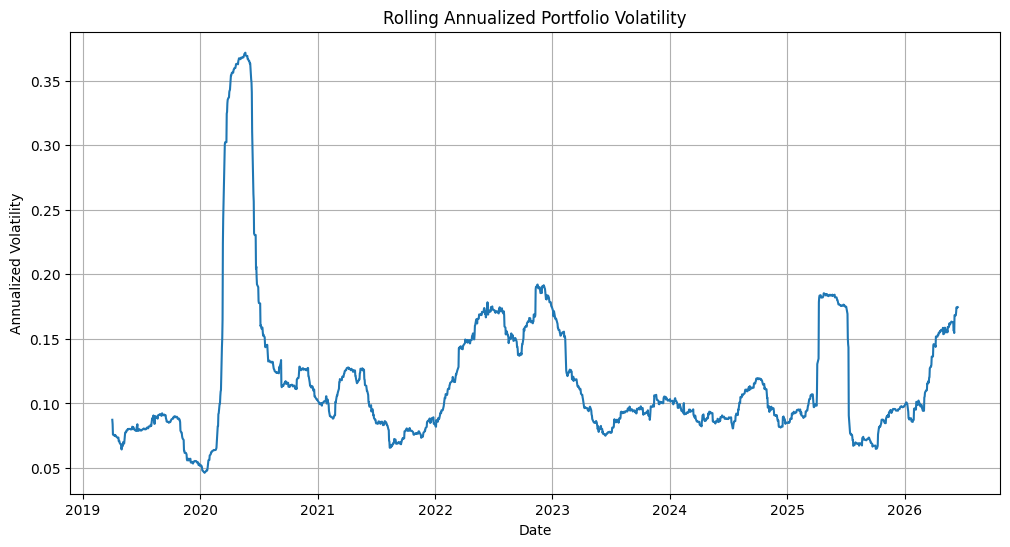

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(rolling_annualized_volatility)
plt.title("Rolling Annualized Portfolio Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.grid(True)
plt.show()

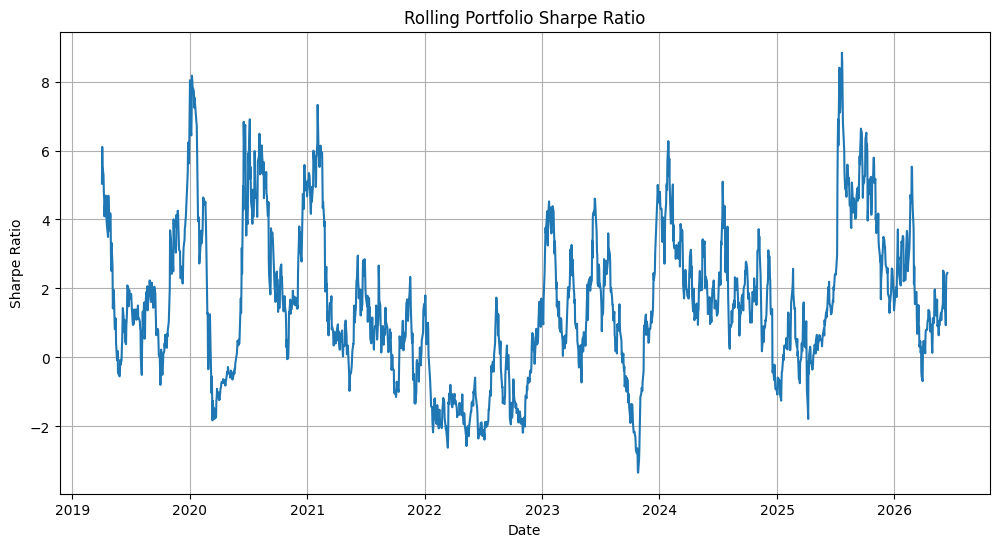

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(rolling_sharpe_ratio)
plt.title("Rolling Portfolio Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.show()

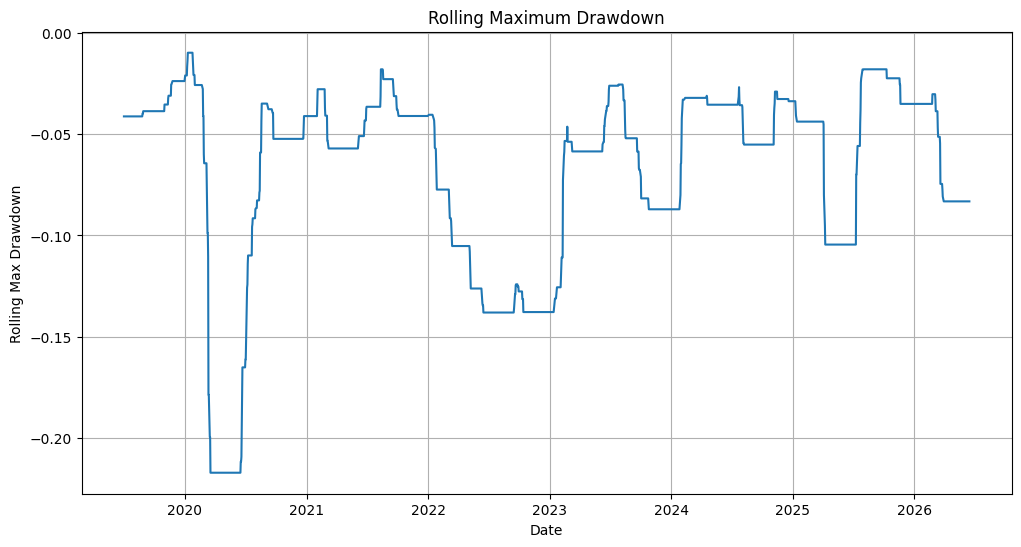

In [43]:
rolling_max = cumulative_returns.rolling(window=rolling_window).max()
rolling_drawdown = cumulative_returns / rolling_max - 1

rolling_max_drawdown = rolling_drawdown.rolling(window=rolling_window).min()

plt.figure(figsize=(12, 6))
plt.plot(rolling_max_drawdown)
plt.title("Rolling Maximum Drawdown")
plt.xlabel("Date")
plt.ylabel("Rolling Max Drawdown")
plt.grid(True)
plt.show()

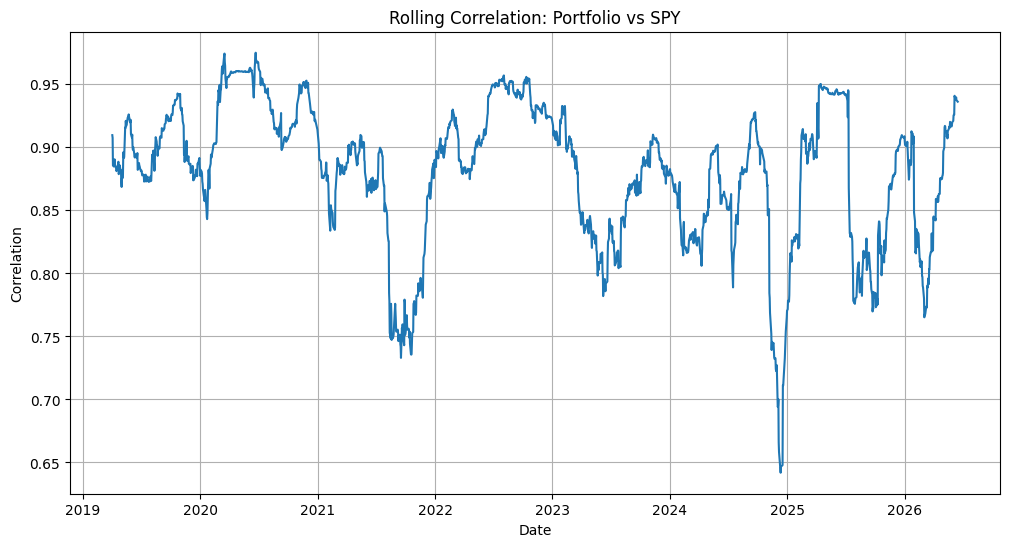

In [44]:
rolling_corr_spy = portfolio_returns.rolling(window=rolling_window).corr(returns["SPY"])

plt.figure(figsize=(12, 6))
plt.plot(rolling_corr_spy)
plt.title("Rolling Correlation: Portfolio vs SPY")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()

In [45]:
rolling_risk_summary = pd.DataFrame({
    "Metric": [
        "Highest Rolling Annualized Volatility",
        "Lowest Rolling Annualized Volatility",
        "Highest Rolling Sharpe Ratio",
        "Lowest Rolling Sharpe Ratio",
        "Worst Rolling Max Drawdown",
        "Highest Rolling Correlation with SPY",
        "Lowest Rolling Correlation with SPY"
    ],
    "Value": [
        rolling_annualized_volatility.max(),
        rolling_annualized_volatility.min(),
        rolling_sharpe_ratio.max(),
        rolling_sharpe_ratio.min(),
        rolling_max_drawdown.min(),
        rolling_corr_spy.max(),
        rolling_corr_spy.min()
    ]
})

rolling_risk_summary_display = rolling_risk_summary.copy()

percentage_metrics = [
    "Highest Rolling Annualized Volatility",
    "Lowest Rolling Annualized Volatility",
    "Worst Rolling Max Drawdown"
]

rolling_risk_summary_display["Value"] = rolling_risk_summary_display.apply(
    lambda row: f"{row['Value']:.2%}" if row["Metric"] in percentage_metrics else f"{row['Value']:.2f}",
    axis=1
)

rolling_risk_summary_display

,Metric,Value
0,Highest Rolling Annualized Volatility,37.16%
1,Lowest Rolling Annualized Volatility,4.63%
2,Highest Rolling Sharpe Ratio,8.84
3,Lowest Rolling Sharpe Ratio,-3.34
4,Worst Rolling Max Drawdown,-21.70%
5,Highest Rolling Correlation with SPY,0.98
6,Lowest Rolling Correlation with SPY,0.64


### Rolling risk interpretation

The rolling volatility chart shows how the portfolio's risk changed over time.

Periods with higher rolling volatility indicate market environments where the portfolio experienced larger return fluctuations.

The rolling Sharpe ratio shows how the portfolio's risk-adjusted performance changed across different market regimes.

The rolling maximum drawdown chart helps identify periods of persistent downside pressure.

The rolling correlation with SPY shows how closely the portfolio moved with the broad U.S. equity market over time. If this correlation increases during stress periods, the portfolio may provide less diversification exactly when diversification is most needed.

## Advanced Step 12: Compare VaR methods

In this step, I compare three Value at Risk methods:

- Historical VaR
- Parametric VaR
- Monte Carlo VaR

Historical VaR uses the actual historical return distribution.

Parametric VaR assumes returns are normally distributed and uses the portfolio's historical mean and volatility.

Monte Carlo VaR simulates many one-day returns using the portfolio's historical mean and volatility.

Comparing VaR methods is useful because different assumptions can produce different estimates of downside risk.

In [46]:
from scipy.stats import norm

confidence_levels = [0.95, 0.99]

var_comparison_results = []

for confidence_level in confidence_levels:
    tail_probability = 1 - confidence_level
    
    # Historical VaR and CVaR
    historical_var = portfolio_returns.quantile(tail_probability)
    historical_cvar = portfolio_returns[portfolio_returns <= historical_var].mean()
    
    # Parametric VaR and CVaR under normality
    z_score = norm.ppf(tail_probability)
    parametric_var = daily_mean_return + z_score * daily_volatility
    parametric_cvar = daily_mean_return - daily_volatility * norm.pdf(z_score) / tail_probability
    
    # Monte Carlo one-day VaR and CVaR
    simulated_one_day_returns = np.random.normal(
        loc=daily_mean_return,
        scale=daily_volatility,
        size=100000
    )
    
    monte_carlo_var = np.percentile(simulated_one_day_returns, tail_probability * 100)
    monte_carlo_cvar = simulated_one_day_returns[simulated_one_day_returns <= monte_carlo_var].mean()
    
    var_comparison_results.extend([
        {
            "Confidence Level": f"{confidence_level:.0%}",
            "Method": "Historical",
            "VaR": historical_var,
            "CVaR": historical_cvar
        },
        {
            "Confidence Level": f"{confidence_level:.0%}",
            "Method": "Parametric Normal",
            "VaR": parametric_var,
            "CVaR": parametric_cvar
        },
        {
            "Confidence Level": f"{confidence_level:.0%}",
            "Method": "Monte Carlo Normal",
            "VaR": monte_carlo_var,
            "CVaR": monte_carlo_cvar
        }
    ])

var_comparison = pd.DataFrame(var_comparison_results)

var_comparison

,Confidence Level,Method,VaR,CVaR
0,95%,Historical,-0.012095,-0.019153
1,95%,Parametric Normal,-0.013059,-0.016498
2,95%,Monte Carlo Normal,-0.013078,-0.016505
3,99%,Historical,-0.020760,-0.034111
4,99%,Parametric Normal,-0.018669,-0.021458
5,99%,Monte Carlo Normal,-0.018658,-0.021369


In [47]:
var_comparison_display = var_comparison.copy()

var_comparison_display["VaR"] = var_comparison_display["VaR"].map(lambda x: f"{x:.2%}")
var_comparison_display["CVaR"] = var_comparison_display["CVaR"].map(lambda x: f"{x:.2%}")

var_comparison_display

,Confidence Level,Method,VaR,CVaR
0,95%,Historical,-1.21%,-1.92%
1,95%,Parametric Normal,-1.31%,-1.65%
2,95%,Monte Carlo Normal,-1.31%,-1.65%
3,99%,Historical,-2.08%,-3.41%
4,99%,Parametric Normal,-1.87%,-2.15%
5,99%,Monte Carlo Normal,-1.87%,-2.14%


In [48]:
var_plot_data = var_comparison.copy()

var_plot_data["VaR Loss"] = -var_plot_data["VaR"]
var_plot_data["CVaR Loss"] = -var_plot_data["CVaR"]

var_plot_data

,Confidence Level,Method,VaR,CVaR,VaR Loss,CVaR Loss
0,95%,Historical,-0.012095,-0.019153,0.012095,0.019153
1,95%,Parametric Normal,-0.013059,-0.016498,0.013059,0.016498
2,95%,Monte Carlo Normal,-0.013078,-0.016505,0.013078,0.016505
3,99%,Historical,-0.020760,-0.034111,0.020760,0.034111
4,99%,Parametric Normal,-0.018669,-0.021458,0.018669,0.021458
5,99%,Monte Carlo Normal,-0.018658,-0.021369,0.018658,0.021369


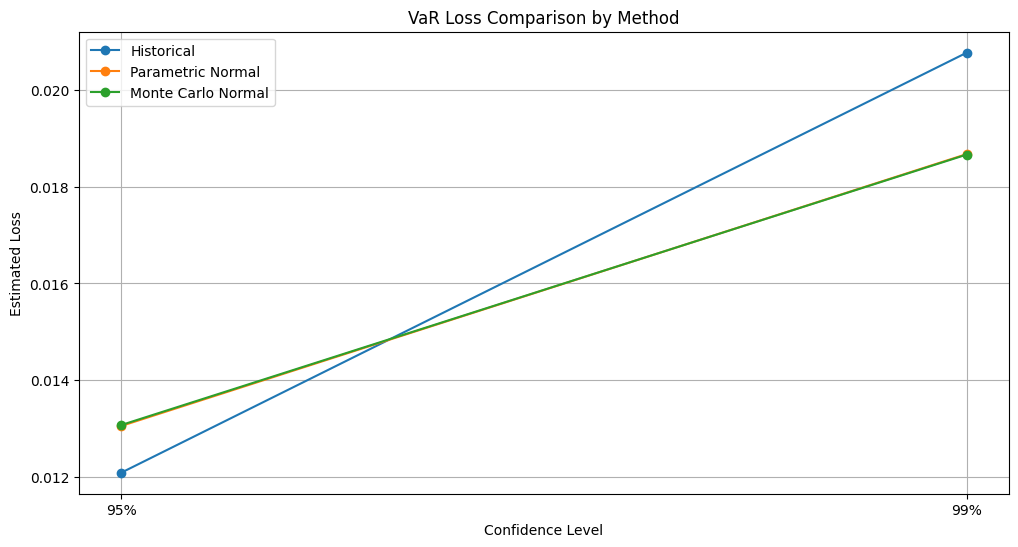

In [49]:
plt.figure(figsize=(12, 6))

for method in var_plot_data["Method"].unique():
    method_data = var_plot_data[var_plot_data["Method"] == method]
    plt.plot(
        method_data["Confidence Level"],
        method_data["VaR Loss"],
        marker="o",
        label=method
    )

plt.title("VaR Loss Comparison by Method")
plt.xlabel("Confidence Level")
plt.ylabel("Estimated Loss")
plt.legend()
plt.grid(True)
plt.show()

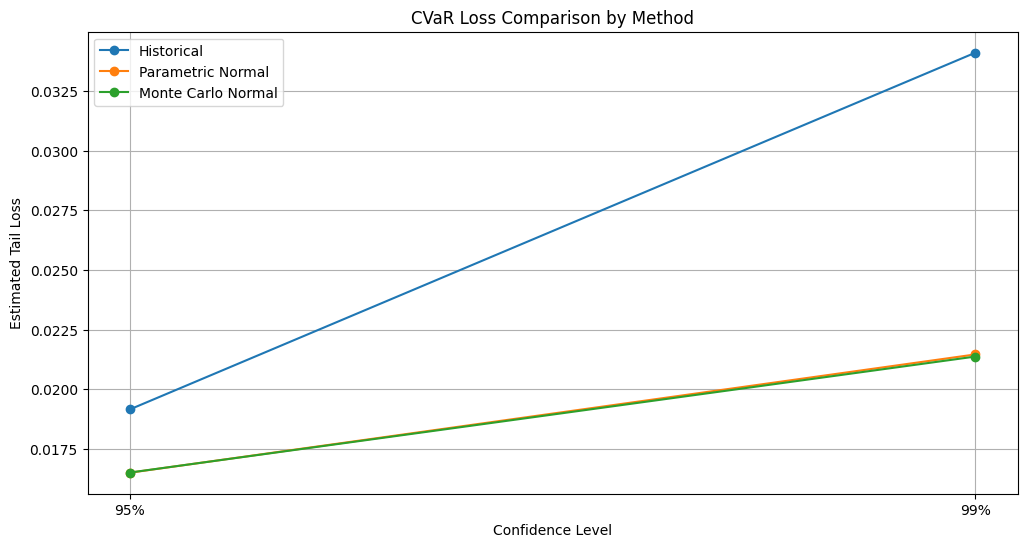

In [50]:
plt.figure(figsize=(12, 6))

for method in var_plot_data["Method"].unique():
    method_data = var_plot_data[var_plot_data["Method"] == method]
    plt.plot(
        method_data["Confidence Level"],
        method_data["CVaR Loss"],
        marker="o",
        label=method
    )

plt.title("CVaR Loss Comparison by Method")
plt.xlabel("Confidence Level")
plt.ylabel("Estimated Tail Loss")
plt.legend()
plt.grid(True)
plt.show()

### VaR method comparison interpretation

The historical VaR method uses actual historical portfolio returns, so it reflects the observed return distribution during the selected analysis period.

The parametric VaR method assumes returns are normally distributed. This makes the method simple, but it may underestimate extreme losses if actual returns have fat tails.

The Monte Carlo VaR method in this version also assumes normally distributed returns, but estimates downside risk through simulation rather than a closed-form formula.

The 99% VaR and CVaR estimates are expected to show larger losses than the 95% estimates because they focus on more extreme downside outcomes.

If historical VaR or CVaR is meaningfully worse than parametric VaR or Monte Carlo normal VaR, this may suggest that the portfolio return distribution has downside tail risk that is not fully captured by a normal distribution assumption.

## Advanced Step 13: VaR backtesting

In this step, I backtest the historical VaR model.

VaR backtesting compares the model's estimated loss threshold against actual portfolio returns.

A VaR exception occurs when the actual portfolio return is worse than the VaR estimate.

For example, with a 95% one-day VaR model, we expect losses to exceed the VaR threshold approximately 5% of the time.

This section uses a rolling historical VaR approach.

In [51]:
backtest_window = 252
backtest_confidence_level = 0.95
backtest_tail_probability = 1 - backtest_confidence_level

rolling_historical_var_95 = portfolio_returns.rolling(
    window=backtest_window
).quantile(backtest_tail_probability)

var_backtest = pd.DataFrame({
    "Portfolio Return": portfolio_returns,
    "Rolling Historical VaR 95%": rolling_historical_var_95
}).dropna()

var_backtest["VaR Exception"] = (
    var_backtest["Portfolio Return"] < var_backtest["Rolling Historical VaR 95%"]
)

var_backtest.head()

,Portfolio Return,Rolling Historical VaR 95%,VaR Exception
Date,,,
2020-01-02,0.009665,-0.006801,False
2020-01-03,-0.004893,-0.006617,False
2020-01-06,0.002001,-0.006617,False
2020-01-07,-0.000827,-0.006617,False
2020-01-08,0.002057,-0.006617,False


In [52]:
total_observations = len(var_backtest)
actual_exceptions = var_backtest["VaR Exception"].sum()
expected_exceptions = total_observations * backtest_tail_probability
exception_rate = actual_exceptions / total_observations

var_backtest_summary = pd.DataFrame({
    "Metric": [
        "Backtest Window",
        "Confidence Level",
        "Total Observations",
        "Expected Exceptions",
        "Actual Exceptions",
        "Expected Exception Rate",
        "Actual Exception Rate"
    ],
    "Value": [
        backtest_window,
        f"{backtest_confidence_level:.0%}",
        total_observations,
        expected_exceptions,
        actual_exceptions,
        f"{backtest_tail_probability:.2%}",
        f"{exception_rate:.2%}"
    ]
})

var_backtest_summary

,Metric,Value
0,Backtest Window,252
1,Confidence Level,95%
2,Total Observations,1621
3,Expected Exceptions,81.05
4,Actual Exceptions,96
5,Expected Exception Rate,5.00%
6,Actual Exception Rate,5.92%


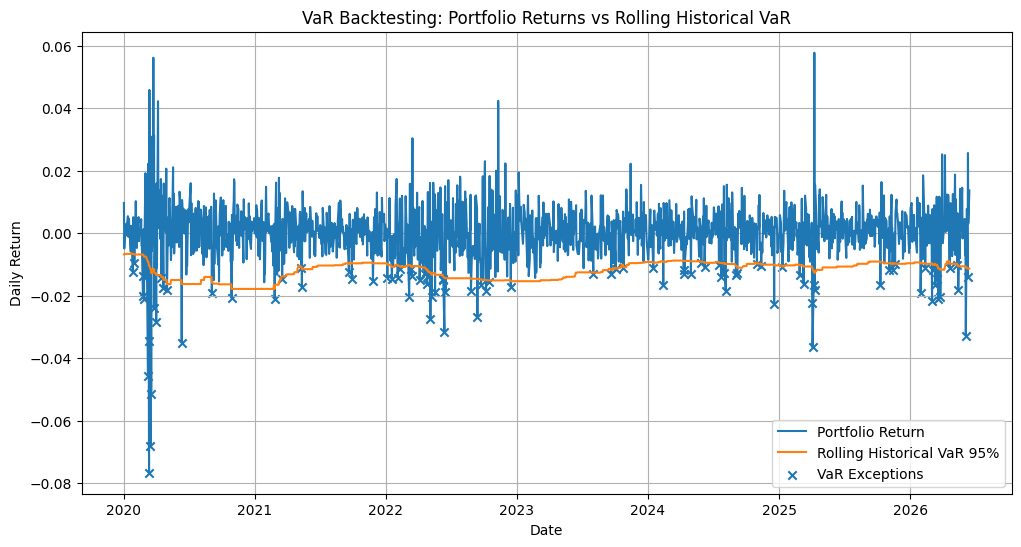

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(var_backtest.index, var_backtest["Portfolio Return"], label="Portfolio Return")
plt.plot(var_backtest.index, var_backtest["Rolling Historical VaR 95%"], label="Rolling Historical VaR 95%")

exceptions = var_backtest[var_backtest["VaR Exception"]]

plt.scatter(
    exceptions.index,
    exceptions["Portfolio Return"],
    label="VaR Exceptions",
    marker="x"
)

plt.title("VaR Backtesting: Portfolio Returns vs Rolling Historical VaR")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
from scipy.stats import chi2

def kupiec_pof_test(num_exceptions, num_observations, tail_probability):
    """
    Kupiec Proportion of Failures test.

    Null hypothesis:
    The observed exception rate is equal to the expected exception rate.

    A low p-value suggests the VaR model may not be calibrated well.
    """
    if num_exceptions == 0 or num_exceptions == num_observations:
        return np.nan, np.nan

    observed_exception_rate = num_exceptions / num_observations

    likelihood_null = (
        (1 - tail_probability) ** (num_observations - num_exceptions)
        * tail_probability ** num_exceptions
    )

    likelihood_alternative = (
        (1 - observed_exception_rate) ** (num_observations - num_exceptions)
        * observed_exception_rate ** num_exceptions
    )

    test_statistic = -2 * np.log(likelihood_null / likelihood_alternative)
    p_value = 1 - chi2.cdf(test_statistic, df=1)

    return test_statistic, p_value


kupiec_statistic, kupiec_p_value = kupiec_pof_test(
    actual_exceptions,
    total_observations,
    backtest_tail_probability
)

kupiec_results = pd.DataFrame({
    "Metric": [
        "Kupiec Test Statistic",
        "Kupiec Test p-value"
    ],
    "Value": [
        kupiec_statistic,
        kupiec_p_value
    ]
})

kupiec_results

,Metric,Value
0,Kupiec Test Statistic,2.747741
1,Kupiec Test p-value,0.097392


In [55]:
if kupiec_p_value < 0.05:
    kupiec_interpretation = (
        "The p-value is below 0.05, suggesting that the VaR model may not be well calibrated."
    )
else:
    kupiec_interpretation = (
        "The p-value is above 0.05, so there is not enough evidence to reject the VaR model's exception rate calibration."
    )

kupiec_interpretation

"The p-value is above 0.05, so there is not enough evidence to reject the VaR model's exception rate calibration."

### VaR backtesting interpretation

The VaR backtest compares actual portfolio returns against the rolling historical VaR estimate.

A VaR exception occurs when the portfolio return is lower than the VaR threshold.

For a 95% one-day VaR model, the expected exception rate is approximately 5%. If the actual exception rate is much higher than 5%, the model may be underestimating downside risk. If the actual exception rate is much lower than 5%, the model may be too conservative.

The Kupiec Proportion of Failures test evaluates whether the observed exception rate is statistically different from the expected exception rate.

A key limitation is that this backtest focuses on the number of exceptions, not whether exceptions are clustered during crisis periods. A future improvement could add independence testing or conditional coverage testing.

## Advanced Step 14: Correlated asset-level Monte Carlo simulation

In this step, I improve the Monte Carlo simulation by modeling asset-level returns instead of only portfolio-level returns.

The previous Monte Carlo simulation used the portfolio's historical mean return and volatility. This was useful as a baseline, but it did not explicitly model how individual assets move together.

This version simulates returns for each asset using the historical mean return vector and covariance matrix. The simulated asset returns are then combined using portfolio weights.

This allows the simulation to preserve the historical relationship between assets, including volatility and correlation.

In [56]:
np.random.seed(42)

num_asset_simulations = 10000
forecast_horizon_days = 252
initial_portfolio_value = 10_000

asset_mean_returns = returns.mean()
asset_cov_matrix = returns.cov()

asset_mean_returns

Ticker
AGG    0.000081
EEM    0.000487
EFA    0.000488
GLD    0.000694
IWM    0.000593
QQQ    0.000977
SPY    0.000724
dtype: float64

In [57]:
asset_cov_matrix

Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
Ticker,,,,,,,
AGG,0.000014,0.000009,0.000010,0.000013,0.000011,0.000009,0.000008
EEM,0.000009,0.000183,0.000131,0.000040,0.000152,0.000150,0.000125
EFA,0.000010,0.000131,0.000136,0.000031,0.000149,0.000134,0.000122
GLD,0.000013,0.000040,0.000031,0.000121,0.000023,0.000023,0.000017
IWM,0.000011,0.000152,0.000149,0.000023,0.000251,0.000183,0.000168
QQQ,0.000009,0.000150,0.000134,0.000023,0.000183,0.000229,0.000174
SPY,0.000008,0.000125,0.000122,0.000017,0.000168,0.000174,0.000151


In [58]:
# Add a tiny numerical adjustment to help ensure the covariance matrix is positive definite
jitter = 1e-10
adjusted_cov_matrix = asset_cov_matrix + np.eye(len(tickers)) * jitter

cholesky_matrix = np.linalg.cholesky(adjusted_cov_matrix)

cholesky_matrix.shape

(7, 7)

In [59]:
# Generate independent random shocks
random_shocks = np.random.normal(
    size=(forecast_horizon_days, num_asset_simulations, len(tickers))
)

# Convert independent shocks into correlated asset returns
correlated_asset_returns = random_shocks @ cholesky_matrix.T + asset_mean_returns.values

correlated_asset_returns.shape

/var/folders/vt/wr33bckn4_1fymdsc82x2ggm0000gn/T/ipykernel_13416/1488418913.py:7: RuntimeWarning: divide by zero encountered in matmul
  correlated_asset_returns = random_shocks @ cholesky_matrix.T + asset_mean_returns.values
/var/folders/vt/wr33bckn4_1fymdsc82x2ggm0000gn/T/ipykernel_13416/1488418913.py:7: RuntimeWarning: overflow encountered in matmul
  correlated_asset_returns = random_shocks @ cholesky_matrix.T + asset_mean_returns.values
/var/folders/vt/wr33bckn4_1fymdsc82x2ggm0000gn/T/ipykernel_13416/1488418913.py:7: RuntimeWarning: invalid value encountered in matmul
  correlated_asset_returns = random_shocks @ cholesky_matrix.T + asset_mean_returns.values


(252, 10000, 7)

In [60]:
# Convert asset-level simulated returns into portfolio-level simulated returns
asset_level_portfolio_returns = correlated_asset_returns @ weights_series.values

asset_level_portfolio_paths = initial_portfolio_value * (1 + asset_level_portfolio_returns).cumprod(axis=0)

asset_level_portfolio_paths.shape

/var/folders/vt/wr33bckn4_1fymdsc82x2ggm0000gn/T/ipykernel_13416/2887375181.py:2: RuntimeWarning: divide by zero encountered in matmul
  asset_level_portfolio_returns = correlated_asset_returns @ weights_series.values
/var/folders/vt/wr33bckn4_1fymdsc82x2ggm0000gn/T/ipykernel_13416/2887375181.py:2: RuntimeWarning: overflow encountered in matmul
  asset_level_portfolio_returns = correlated_asset_returns @ weights_series.values
/var/folders/vt/wr33bckn4_1fymdsc82x2ggm0000gn/T/ipykernel_13416/2887375181.py:2: RuntimeWarning: invalid value encountered in matmul
  asset_level_portfolio_returns = correlated_asset_returns @ weights_series.values


(252, 10000)

In [61]:
asset_level_ending_values = asset_level_portfolio_paths[-1, :]
asset_level_one_year_returns = asset_level_ending_values / initial_portfolio_value - 1

asset_level_simulation_summary = pd.DataFrame({
    "Metric": [
        "Mean Ending Value",
        "Median Ending Value",
        "5th Percentile Ending Value",
        "95th Percentile Ending Value",
        "Worst Simulated Ending Value",
        "Best Simulated Ending Value",
        "Mean One-Year Return",
        "Median One-Year Return",
        "5th Percentile One-Year Return",
        "95th Percentile One-Year Return"
    ],
    "Value": [
        asset_level_ending_values.mean(),
        np.median(asset_level_ending_values),
        np.percentile(asset_level_ending_values, 5),
        np.percentile(asset_level_ending_values, 95),
        asset_level_ending_values.min(),
        asset_level_ending_values.max(),
        asset_level_one_year_returns.mean(),
        np.median(asset_level_one_year_returns),
        np.percentile(asset_level_one_year_returns, 5),
        np.percentile(asset_level_one_year_returns, 95)
    ]
})

asset_level_simulation_summary_display = asset_level_simulation_summary.copy()

money_metrics = [
    "Mean Ending Value",
    "Median Ending Value",
    "5th Percentile Ending Value",
    "95th Percentile Ending Value",
    "Worst Simulated Ending Value",
    "Best Simulated Ending Value"
]

asset_level_simulation_summary_display["Value"] = asset_level_simulation_summary_display.apply(
    lambda row: f"${row['Value']:,.2f}" if row["Metric"] in money_metrics else f"{row['Value']:.2%}",
    axis=1
)

asset_level_simulation_summary_display

,Metric,Value
0,Mean Ending Value,"$11,293.47"
1,Median Ending Value,"$11,215.16"
2,5th Percentile Ending Value,"$9,015.33"
3,95th Percentile Ending Value,"$13,839.61"
4,Worst Simulated Ending Value,"$7,096.47"
5,Best Simulated Ending Value,"$17,840.21"
6,Mean One-Year Return,12.93%
7,Median One-Year Return,12.15%
8,5th Percentile One-Year Return,-9.85%
9,95th Percentile One-Year Return,38.40%


In [62]:
asset_level_monte_carlo_var_95 = np.percentile(asset_level_one_year_returns, 5)
asset_level_monte_carlo_cvar_95 = asset_level_one_year_returns[
    asset_level_one_year_returns <= asset_level_monte_carlo_var_95
].mean()

asset_level_mc_risk_summary = pd.DataFrame({
    "Metric": [
        "Asset-Level Monte Carlo VaR 95% - One Year",
        "Asset-Level Monte Carlo CVaR 95% - One Year"
    ],
    "Value": [
        asset_level_monte_carlo_var_95,
        asset_level_monte_carlo_cvar_95
    ]
})

asset_level_mc_risk_summary["Value"] = asset_level_mc_risk_summary["Value"].map(lambda x: f"{x:.2%}")

asset_level_mc_risk_summary

,Metric,Value
0,Asset-Level Monte Carlo VaR 95% - One Year,-9.85%
1,Asset-Level Monte Carlo CVaR 95% - One Year,-14.68%


In [63]:
asset_level_percentiles = np.percentile(
    asset_level_portfolio_paths,
    [5, 25, 50, 75, 95],
    axis=1
)

asset_level_percentile_paths = pd.DataFrame({
    "5th Percentile": asset_level_percentiles[0],
    "25th Percentile": asset_level_percentiles[1],
    "Median": asset_level_percentiles[2],
    "75th Percentile": asset_level_percentiles[3],
    "95th Percentile": asset_level_percentiles[4]
})

asset_level_percentile_paths.head()

,5th Percentile,25th Percentile,Median,75th Percentile,95th Percentile
0,9869.577160,9949.956637,10005.284146,10061.529251,10140.980022
1,9817.339145,9930.851832,10009.459666,10088.364511,10201.839107
2,9782.866344,9917.727340,10013.803927,10110.679616,10252.636405
3,9749.650321,9907.288855,10014.855432,10129.161176,10290.245910
4,9721.792880,9897.352472,10023.209902,10146.489890,10327.674089


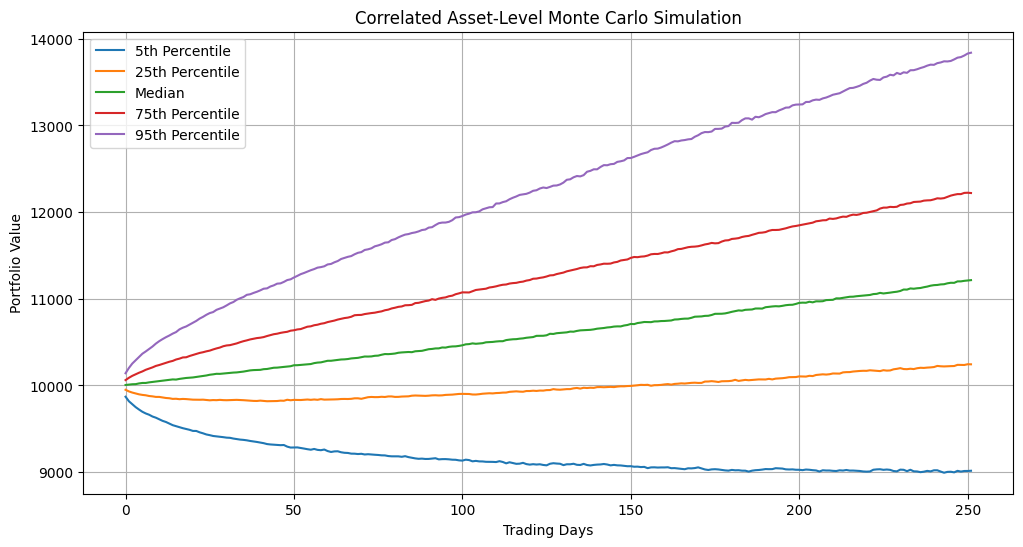

In [64]:
plt.figure(figsize=(12, 6))

plt.plot(asset_level_percentile_paths["5th Percentile"], label="5th Percentile")
plt.plot(asset_level_percentile_paths["25th Percentile"], label="25th Percentile")
plt.plot(asset_level_percentile_paths["Median"], label="Median")
plt.plot(asset_level_percentile_paths["75th Percentile"], label="75th Percentile")
plt.plot(asset_level_percentile_paths["95th Percentile"], label="95th Percentile")

plt.title("Correlated Asset-Level Monte Carlo Simulation")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [65]:
monte_carlo_model_comparison = pd.DataFrame({
    "Model": [
        "Portfolio-Level Normal Monte Carlo",
        "Correlated Asset-Level Monte Carlo"
    ],
    "One-Year VaR 95%": [
        monte_carlo_var_95,
        asset_level_monte_carlo_var_95
    ],
    "One-Year CVaR 95%": [
        monte_carlo_cvar_95,
        asset_level_monte_carlo_cvar_95
    ]
})

monte_carlo_model_comparison_display = monte_carlo_model_comparison.copy()

monte_carlo_model_comparison_display["One-Year VaR 95%"] = monte_carlo_model_comparison_display[
    "One-Year VaR 95%"
].map(lambda x: f"{x:.2%}")

monte_carlo_model_comparison_display["One-Year CVaR 95%"] = monte_carlo_model_comparison_display[
    "One-Year CVaR 95%"
].map(lambda x: f"{x:.2%}")

monte_carlo_model_comparison_display

,Model,One-Year VaR 95%,One-Year CVaR 95%
0,Portfolio-Level Normal Monte Carlo,-9.68%,-14.43%
1,Correlated Asset-Level Monte Carlo,-9.85%,-14.68%


### Correlated asset-level Monte Carlo interpretation

The correlated asset-level Monte Carlo simulation is more realistic than the original portfolio-level simulation because it models each asset separately.

This allows the model to preserve the historical covariance structure between assets. In other words, the simulation considers not only each asset's volatility, but also how the assets tend to move together.

The results can be compared with the original portfolio-level Monte Carlo simulation. If the VaR and CVaR estimates are similar, then the simpler portfolio-level model may be a reasonable approximation. If the estimates differ meaningfully, then asset-level correlation effects may be important.

This model is still limited because it assumes normally distributed asset returns and uses historical covariance as a future estimate. It does not capture fat tails, volatility clustering, regime changes, or changing correlations during market stress.